### 딥러닝
- 딥러닝이란?
 - 인간의 신경망을 모방하여 학습하고 예측하는 기술
 - 대량의 데이터에서 복잡한 패턴, 규칙을 찾아내는 능력이 뛰어나다.
 - 머신러닝에 비해 다양한 상황 또는 유연한 사고가 가능하다.(사람처럼)
 - 인간의 뉴런 == 딥러닝 선형모델
 - 주로 컴퓨터비전, 자연어처리, 음성분석 등에 많이 사용된다.

### 머신러닝과 딥러닝 사용법 사이
- 머신러닝
  - 모델을 불러오는 작업(완성된 객체) -> 모델학습 -> 모델예측 -> 모델 평가
  - 완제품 로봇에서 팔이나 다리를 움직이는 정도를 조절가능하다.
- 딥러닝
  - 모델을 불러오는 작업(모델을 우리가 직접 설계 및 구성이 가능하다.) -> 모델학습 -> 모델예측 -> 모델평가
  - 부품을 통해 우리가 직접 로봇을 조립하여 원하는 모양의 로봇을 만들 수 있다.

In [5]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# 현재 내 경로 확인 방법
!pwd

/content


In [7]:
# 내가 사용할 폴더 경로 연결
%cd /content/drive/MyDrive/Colab Notebooks/딥러닝

/content/drive/MyDrive/Colab Notebooks/딥러닝


In [8]:
!pwd
# 사용할 딥러닝 폴더에 연결이 됐다.

/content/drive/MyDrive/Colab Notebooks/딥러닝


In [9]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# 데이터 불러오기
data = pd.read_csv('./data/student-mat.csv', delimiter=';')
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [11]:
# 데이터 정보확인
data.info()
# 라벨데이터(정답) -> G3

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

| 컬럼 이름       | 설명                             |
|-----------------|----------------------------------|
| school          | 학교 (GP - Gabriel Pereira, MS - Mousinho da Silveira) |
| sex             | 성별 (F - Female, M - Male)      |
| age             | 나이                             |
| address         | 주소 유형 (U - Urban, R - Rural) |
| famsize         | 가족 크기 (LE3 - 3명 이하, GT3 - 3명 초과) |
| Pstatus         | 부모 동거 상태 (T - 함께, A - 별거) |
| Medu            | 어머니 교육 수준 (0 - 없음, 1 - 초등, 2 - 중등, 3 - 고등, 4 - 대졸) |
| Fedu            | 아버지 교육 수준 (0 - 없음, 1 - 초등, 2 - 중등, 3 - 고등, 4 - 대졸) |
| Mjob            | 어머니 직업 (teacher, health, services, at_home, other) |
| Fjob            | 아버지 직업 (teacher, health, services, at_home, other) |
| reason          | 학교 선택 이유 (home, reputation, course, other) |
| guardian        | 보호자 (mother, father, other)  |
| traveltime      | 통학 시간 (1 - 15분 이하, 2 - 15~30분, 3 - 30분~1시간, 4 - 1시간 초과) |
| studytime       | 주간 공부 시간 (1 - 2시간 이하, 2 - 2~5시간, 3 - 5~10시간, 4 - 10시간 초과) |
| failures        | 과목 낙제 수 (n if 1<=n<3, else 4) |
| schoolsup       | 학교 추가 지원 (yes, no)        |
| famsup          | 가족 추가 지원 (yes, no)        |
| paid            | 과외 수업 참여 (yes, no)        |
| activities      | 학교 외 활동 참여 (yes, no)     |
| nursery         | 유치원 참여 여부 (yes, no)      |
| higher          | 고등교육 희망 여부 (yes, no)    |
| internet        | 가정 내 인터넷 접속 여부 (yes, no) |
| romantic        | 로맨틱 관계 여부 (yes, no)      |
| famrel          | 가족 관계의 질 (1 - 매우 나쁨, 5 - 매우 좋음) |
| freetime        | 여가 시간의 양 (1 - 매우 적음, 5 - 매우 많음) |
| goout           | 외출 빈도 (1 - 매우 적음, 5 - 매우 많음) |
| Dalc            | 평일 음주량 (1 - 매우 적음, 5 - 매우 많음) |
| Walc            | 주말 음주량 (1 - 매우 적음, 5 - 매우 많음) |
| health          | 현재 건강 상태 (1 - 매우 나쁨, 5 - 매우 좋음) |
| absences        | 결석 일수                        |
| G1              | 1학기 성적                       |
| G2              | 2학기 성적                       |
| G3              | 최종 성적                        |


### 데이터분리
- X데이터(문제데이터) / y(정답데이터) 분리하기
- train, test 분리

In [12]:
# 문제데이터와 정답 데이터 분리
# X -> studytime, freetime
# y -> G3
X = data[['studytime', 'freetime']] # 컬럼인덱싱은 하나의 컬럼만 가져 올 수 있으므로 [[]] 사용
y = data['G3']

In [13]:
X

,studytime,freetime
0,2,3
1,2,3
2,2,3
3,3,2
4,2,3
...,...,...
390,2,5
391,1,4
392,1,5
393,1,4


In [14]:
y

,G3
0,6
1,6
2,10
3,15
4,10
...,...
390,9
391,16
392,7
393,10


In [15]:
# train / test 나누기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state=5)

In [16]:
# 크기확인
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
# 1. 문제의 수와 정답의 수가 같은지 확인
# 2. 훈련용 데이터와 테스트용 데이터의 입력특성의 수가 같은지 확인

(276, 2)
(119, 2)
(276,)
(119,)


### 머신러닝 사용하기(회귀)
- LinearRegression 모델 사용

In [17]:
# 머신러닝 모델 도구 불러오기
from sklearn.linear_model import LinearRegression # LinearRegression 도구
from sklearn.metrics import mean_squared_error # MSE 확인 도구

# 모델 객체 생성
linear_model = LinearRegression()

# 모델 학습
linear_model.fit(X_train, y_train)

# 모델 평가
linear_model.score(X_test, y_test)

-0.005807850525840097

In [18]:
# MSE 확인
pre = linear_model.predict(X_test)

mse = mean_squared_error(y_test, pre)
mse

21.72675646101634

### 딥러닝 모델 사용
- TensorFlow 사용하기
  - 신경망 구조 설계
  - 학습 방법 설정
  - 학습
  - 예측 및 평가

In [19]:
# 도구 불러오기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer
from tensorflow.keras.layers import Dense

# Sequential : 뼈대를 생성하는 도구
# InputLayer : 입력층을 쌓을 때 사용하는 도구 중 하나 (하나만 있는것 아니다.)
# Dense : 은닉층(중간층), 출력층을 쌓을 때 사용하는 도구

### 딥러닝 구조
- Sequential : 뼈대를 구축
- 입력층 : 데이터가 들어오는 층
- 중간층(은닉층) : 실제 학습이 진행되는 층<br>(예측을 위하여 여러가지 학습이 진행) -> 실제 성능과 연관이 있는 층
- 출력층 : 결과를 예측하는 층  

## [신경망 구조 설계진행]

In [20]:
# 1. 뼈대 생성
model = Sequential()

# 입력층 쌓기
model.add(InputLayer(shape=(2,))) # 입력 특성 2개

# 중간층(은닉층) 쌓기 -> 학습의 성능을 설정하는 층 (원하는 수 만큼 층 설정 가능)
model.add(Dense(units=10, activation='sigmoid'))
# unit : 퍼셉트론(신경망)의 개수 설정 -> 많으면 학습능력이 올라 갈 수 있음 (무조건 아님)
# -> 선형회귀모델 몇 개 쓸것인가?
# activation : 활성화 함수 -> 사람처럼 생각 할 수 있도록 도와주는 기능
# unit의 개수를 항아리 모양으로 쌓는것이 일반적이다. 10,20,30,20,10 이런식으로!

# 출력층 쌓기 -> 결과를 출력하는 층
model.add(Dense(units = 1, activation='linear'))
# 출력층은 내가 예측하고자하는 Label에 따라 다르게 설정
# 회귀문제 일 경우 unit의 개수는 1개 / activation = 'linear'
# 이진분류 일 경우 unit의 개수는 1개 / activation = 'sigmoid'
# 다중분류 일 경우 unit의 개수는 Class의 개수만큼 / activation = 'softmax'

In [21]:
# 2. 학습방법 및 평가 방법 설정
model.compile(
    loss='mean_squared_error', # 오차 계산 방법 (회귀->mean_squared_error)
    optimizer = 'SGD', # 최적화 함수 -> 오차를 줄여나가는 방법 (경사하강법)
    metrics=['mse'] # 평가지표 (우선은 MSE로 평가)
)

In [22]:
# 3. 신경망 모델 학습
his = model.fit(X_train,y_train, validation_split=0.2, epochs=20)
# validation_split : 검증용 데이터 분리(랜덤으로, 1 epoch당)
# epochs : 학습 반복 횟수

# split -> 비율로 쪼개갰다.
# data -> 데이터를 분리시켜 넣겠다.

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 86.9389 - mse: 86.9389 - val_loss: 46.1064 - val_mse: 46.1064
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 31.0594 - mse: 31.0594 - val_loss: 24.8225 - val_mse: 24.8225
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 22.2257 - mse: 22.2257 - val_loss: 21.7684 - val_mse: 21.7684
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 21.2741 - mse: 21.2741 - val_loss: 21.2840 - val_mse: 21.2840
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 21.1047 - mse: 21.1047 - val_loss: 21.0459 - val_mse: 21.0459
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 21.0093 - mse: 21.0093 - val_loss: 20.7100 - val_mse: 20.7100
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 20.9839 - mse: 20.9839 - val_loss: 20.7164 - val_mse: 20.7164
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 20.9442 - mse: 20.9442 - val_loss: 20.8388 - val_mse: 20.8388
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

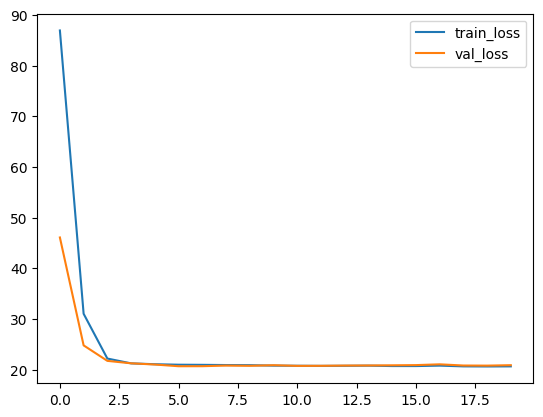

In [23]:
# 학습 결과 시각화
plt.plot(his.history['loss'], label='train_loss')
plt.plot(his.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

### 추가 과제>> 입력특성을 4개로 설정
- studytime
- freetime
- G1
- G2

In [24]:
# 문제데이터와 정답 데이터 분리
X = data[['studytime', 'freetime', 'G1', 'G2']]
y = data['G3']

# train / test 나누기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state=5)

# 크기확인
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(276, 4)
(119, 4)
(276,)
(119,)


In [25]:
# 1. 뼈대 생성
model = Sequential()

# 입력층 쌓기
model.add(InputLayer(shape=(4,))) # 입력 특성 4개

# 중간층(은닉층) 쌓기 -> 학습의 성능을 설정하는 층 (원하는 수 만큼 층 설정 가능)
model.add(Dense(units=10, activation='sigmoid'))

# 출력층 쌓기 -> 결과를 출력하는 층
model.add(Dense(units = 1, activation='linear'))

In [26]:
# 2. 학습방법 및 평가 방법 설정
model.compile(
    loss='mean_squared_error', # 오차 계산 방법 (회귀)
    optimizer = 'SGD', # 최적화 함수 -> 오차를 줄여나가는 방법 (경사하강법)
    metrics=['mse'] # 평가지표 (우선은 MSE로 평가)
)

In [27]:
# 3. 신경망 모델 학습
his = model.fit(X_train,y_train, validation_split=0.2, epochs=20)
# validation_split : 검증용 데이터 분리
# epochs : 학습 횟수

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 63.1801 - mse: 63.1801 - val_loss: 28.3218 - val_mse: 28.3218
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 21.7130 - mse: 21.7130 - val_loss: 18.7250 - val_mse: 18.7250
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 17.9821 - mse: 17.9821 - val_loss: 16.6647 - val_mse: 16.6647
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 16.2674 - mse: 16.2674 - val_loss: 15.3693 - val_mse: 15.3693
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 15.7313 - mse: 15.7313 - val_loss: 15.8582 - val_mse: 15.8582
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 17.4320 - mse: 17.4320 - val_loss: 14.4766 - val_mse: 14.4766
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 14.8509 - mse: 14.8509 - val_loss: 14.3393 - val_mse: 14.3393
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 14.5123 - mse: 14.5123 - val_loss: 12.4263 - val_mse: 12.4263
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step

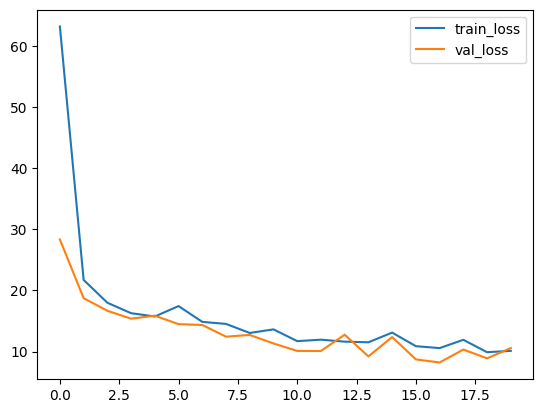

In [28]:
# 학습 결과 시각화
plt.plot(his.history['loss'], label='train_loss')
plt.plot(his.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

### 오후수업> 입력특성을 전체 데이터로 설정
- school ~ G2 : 문제 데이터
- G3 : 정답 데이터

In [29]:
data.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [31]:
# 데이터 분할
X = data.loc[ : ,'school' : 'G2']
y = data['G3']

In [32]:
# 문제데이터 원핫인코딩
X_oh = pd.get_dummies(X, dtype = 'int')
X_oh

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,activities_no,activities_yes,nursery_no,nursery_yes,higher_no,higher_yes,internet_no,internet_yes,romantic_no,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,1,0,0,1,0,1,1,0,1,0
1,17,1,1,1,2,0,5,3,3,1,...,1,0,1,0,0,1,0,1,1,0
2,15,1,1,1,2,3,4,3,2,2,...,1,0,0,1,0,1,0,1,1,0
3,15,4,2,1,3,0,3,2,2,1,...,0,1,0,1,0,1,0,1,0,1
4,16,3,3,1,2,0,4,3,2,1,...,1,0,0,1,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,20,2,2,1,2,2,5,5,4,4,...,1,0,0,1,0,1,1,0,1,0
391,17,3,1,2,1,0,2,4,5,3,...,1,0,1,0,0,1,0,1,1,0
392,21,1,1,1,1,3,5,5,3,3,...,1,0,1,0,0,1,1,0,1,0
393,18,3,2,3,1,0,4,4,1,3,...,1,0,1,0,0,1,0,1,1,0


In [33]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_oh, y,
                                                    random_state = 3,
                                                    test_size = 0.3
                                                   )

In [34]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((276, 58), (119, 58), (276,), (119,))

In [35]:
# 신경망 구조 설계

# 뼈대 설정
model = Sequential()

# 입력층 설정
model.add(InputLayer(shape = (58,)))

# 은닉층 설정
model.add(Dense(units=64, activation='sigmoid'))
model.add(Dense(units=32, activation='sigmoid'))
model.add(Dense(units=16, activation='sigmoid'))

# 출력층 설정
model.add(Dense(units =1)) # activation='linear' 생략가능

In [36]:
# 학습 및 평가방법 설정
model.compile(
    loss = 'mse', # 손실함수 - 어떻게 오류를 볼것인가?
    optimizer = 'SGD', # 어떤 방법으로 모델을 최적화 시킬 것인가 (최적화 함수)
    metrics = ['mse'] # 어떤 지표로 모델을 평가 할 것인가?
)

In [37]:
# 모델 학습
model.fit(X_train, y_train,
          epochs = 20, # 학습반복횟수
          validation_split = 0.2 # 교차검증 20%
          )

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 70.3668 - mse: 70.3668 - val_loss: 30.7489 - val_mse: 30.7488
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 23.0014 - mse: 23.0014 - val_loss: 23.0691 - val_mse: 23.0691
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 20.1548 - mse: 20.1548 - val_loss: 22.9079 - val_mse: 22.9079
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 19.9127 - mse: 19.9127 - val_loss: 22.8654 - val_mse: 22.8654
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 19.8514 - mse: 19.8514 - val_loss: 22.7560 - val_mse: 22.7560
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 19.7170 - mse: 19.7170 - val_loss: 22.6174 - val_mse: 22.6174
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 19.6198 - mse: 19.6198 - val_loss: 22.5083 - val_mse: 22.5083
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 19.5211 - mse: 19.5211 - val_loss: 22.3307 - val_mse: 22.3307
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

In [40]:
# 모델 평가
loss, mse = model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 10.0196 - mse: 10.0196


In [42]:
rmse = np.sqrt(mse)
print(rmse)

3.1653719982634168
